<a href="https://colab.research.google.com/github/Khushitz/MACHINE-LEARNING/blob/MACHINE-LEARNING/LOGISGTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

**Why LOGISTIC REGRESSION Comes Under Classification (Not Regression)**

Even though its name has “regression”, it is actually a classification algorithm.

Why?

Because:

**Linear regression predicts continuous numbers**

Example: price = 500, 700, 1000

Logistic regression predicts categories

0 or 1

Yes or No

Pass or Fail

Logistic regression does NOT give final answer like 0.73.

It converts probability into:

If probability > 0.5 → Class 1

If probability < 0.5 → Class 0
**bold text**
So final output is a category.

That is why it is classification

In [25]:
df = pd.read_csv("/content/insurance_data (1).csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


**The sigmoid function is a mathematical function that converts any number into a value between 0 and 1.**


Logistic Regression works like this:

**Calculate linear equation:**
z=m∗x+b

**Apply sigmoid:**

probability=sigmoid(z)

Apply threshold (usually 0.5):

If probability > 0.5 → Predict 1

Else → Predict 0

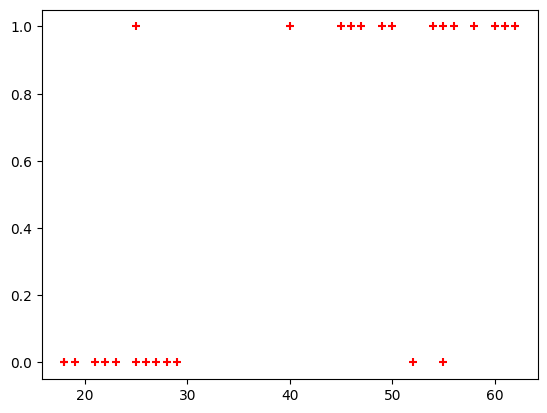

In [26]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

the people who are younger are less likely to buy the insurance on the other hand the people who are elder are more likely to buy the insurance

In [27]:
df.shape

(27, 2)

In [28]:
#train_test_split
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train,y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.1)

df[['age']] is the feature set (input data), selected as a DataFrame with double brackets.
df.bought_insurance is the target variable (output data).
test_size=0.1 specifies that 10% of the data should be allocated to the test set, with the remaining 90% for training.


In [30]:
X_test

,age
2,47
15,55
16,25


In [31]:
X_train

,age
3,52
19,18
20,21
9,61
13,29
23,45
8,62
12,27
1,25
22,40


In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model=LogisticRegression()

In [34]:
model.fit(X_train,y_train)

LogisticRegression()

In [35]:
model.predict(X_test)

array([1, 1, 0])

 The predictions are displayed as a NumPy array: array([1, 1, 0]) MEANS THAT THE FIRST 2 CUSTOMERS WILL BUY THE INSURANCE THAT'WHY IT IS 1 AND ALSO SINCE SEE THE  1 AND THE OTHER ONE IS 0 BECAUSE THEY WILL NOT BUY THE INSURANCE ALSO SINCE WHEN WE SEE THE AGE FROM X_TEST THE FIRST TWO CUSTOMERS AGE ARE MORE HENCE THEY ARE MORE LIKELY TO BUY THE INSURANCE AS COMPARED TO THE 3RD ONE WHO IS 28 YEARS OLD

In [36]:
model.score(X_test,y_test) #i.e shows accuracy of the model which is 1 which shows model is perfect

0.6666666666666666

In [37]:
model.predict_proba(X_test)

array([[0.31793001, 0.68206999],
       [0.10989478, 0.89010522],
       [0.94735566, 0.05264434]])

11% that customer 1 will not buy the insurance and 88% that he will buy the insurance.

In [42]:
model.predict_proba([[23]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.96166286, 0.03833714]])

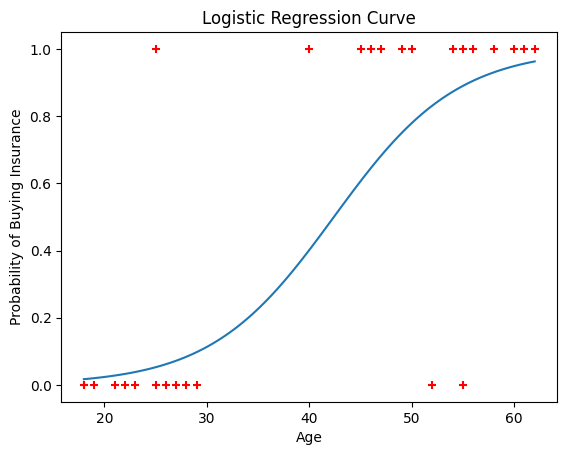

In [44]:
# Create smooth age values
age_range = np.linspace(df.age.min(), df.age.max(), 100)
age_range_df = pd.DataFrame(age_range, columns=['age'])

# Get probabilities
probabilities = model.predict_proba(age_range_df)[:,1]

# Plot
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
plt.plot(age_range, probabilities)

plt.xlabel("Age")
plt.ylabel("Probability of Buying Insurance")
plt.title("Logistic Regression Curve")
plt.show()


**The S-shaped curve indicates that as age increases, the probability of buying insurance also increases, particularly accelerating between ages 30 and 50.**


age_range = np.linspace(df.age.min(), df.age.max(), 100)
What this means:

df.age.min() → smallest age in your data

df.age.max() → biggest age in your data

np.linspace(..., 100) → create 100 numbers between min and max age

👉 So instead of only using 27 real ages,
we create 100 smooth age values.

Why?

Because we want a smooth curve, not zig-zag points

age_range_df = pd.DataFrame(age_range, columns=['age'])
This converts the numbers into a DataFrame.

Why?

Because your model was trained using:

df[['age']]


So it expects a column named age.

probabilities = model.predict_proba(age_range_df)[:,1]
What happens here:

predict_proba() gives probability of:

Class 0

Class 1

Example output:

[[0.8, 0.2],
 [0.7, 0.3],
 [0.1, 0.9]]


First column → probability of NOT buying (0)

Second column → probability of buying (1)


[:,1]
Means:
👉 Take only second column (probability of buying insurance)

So now:

probabilities = chance of buying insurance for each age.


plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
This draws the real data points:

X-axis → Age

Y-axis → 0 or 1

Red + signs → actual people



plt.plot(age_range, probabilities)
This draws the smooth curve showing:

👉 How probability increases as age increases

That curved shape is the sigmoid function.